# 05 · ASR and Video on Real Weights

**Hardware**: 🟡 24GB VRAM. Uses `google/gemma-4-E2B-it` — **audio is native to E2B and E4B only**; the 31B and 26B-A4B checkpoints ship `"audio_config": null`.

The companion [`01_audio_tower_anatomy.ipynb`](01_audio_tower_anatomy.ipynb) derives the arithmetic. This one runs it.

## What you will do

1. Transcribe real speech and confirm the token count is exactly `duration_ms / 40`
2. Ask questions *about* the audio, not just for a transcript — the thing a dedicated ASR model cannot do
3. Feed a video and measure what a clip really costs in context
4. Find the `fps` trap that silently corrupts timestamps

In [1]:
%pip install -q "transformers>=5.14" accelerate torch soundfile librosa requests pillow matplotlib

In [2]:
import io, requests
import numpy as np
import soundfile as sf
import librosa
import torch
from PIL import Image, ImageDraw
from transformers import AutoModelForImageTextToText, AutoProcessor

MODEL_ID = "google/gemma-4-E2B-it"
processor = AutoProcessor.from_pretrained(MODEL_ID, padding_side="left")
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID, dtype="auto", device_map="auto", attn_implementation="sdpa").eval()

print("audio tower present:", model.model.audio_tower is not None)
print("audio_config       :", type(model.config.audio_config).__name__)

  from .autonotebook import tqdm as notebook_tqdm


audio tower present: True
audio_config       : Gemma4AudioConfig


In [3]:
AUDIO_URL = "https://huggingface.co/datasets/eustlb/audio-samples/resolve/main/dude_where_is_my_car.wav"

raw, sr = sf.read(io.BytesIO(requests.get(AUDIO_URL, timeout=120).content))
if raw.ndim > 1:
    raw = raw.mean(axis=1)
audio = librosa.resample(raw.astype(np.float32), orig_sr=sr, target_sr=16000)
print(f"full clip: {len(audio)/16000:.1f}s at 16kHz")

def ask_audio(waveform, prompt, max_new_tokens=200):
    messages = [{"role": "user", "content": [
        {"type": "text", "text": prompt},
        {"type": "audio", "audio": waveform},
    ]}]
    inputs = processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt",
    ).to(model.device, dtype=model.dtype)
    n_audio = int((inputs["input_ids"] == model.config.audio_token_id).sum())
    input_len = inputs["input_ids"].shape[-1]
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return processor.decode(out[0][input_len:], skip_special_tokens=True), n_audio, inputs

full clip: 65.1s at 16kHz


## 1. Transcription, and the 40ms rule

In [4]:
clip = audio[:16000 * 10]                      # 10 seconds
text, n_audio, inputs = ask_audio(clip, "Please transcribe the following audio:")

print(f"clip           : {len(clip)/16000:.1f}s")
print(f"audio tokens   : {n_audio}")
print(f"duration_ms/40 : {len(clip)/16000*1000/40:.0f}")
print(f"predicted      : {processor._compute_audio_num_tokens(clip, 16000)}")
print(f"input_features : {tuple(inputs['input_features'].shape)}  [batch, mel frames, 128 bins]")
print(f"\ntranscript: {text}")

clip           : 10.0s
audio tokens   : 250
duration_ms/40 : 250
predicted      : 250
input_features : (1, 999, 128)  [batch, mel frames, 128 bins]

transcript: Come on. Hurry.


In [5]:
for seconds in (2, 5, 10, 20, 30, 45):
    n = len(audio) // 16000
    if seconds > n:
        continue
    piece = audio[:16000 * seconds]
    pred = processor._compute_audio_num_tokens(piece, 16000)
    print(f"{seconds:3d}s -> {pred:4d} tokens   (duration_ms/40 = {seconds*1000/40:5.0f})"
          f"{'   <- CAPPED at audio_seq_length' if pred >= processor.audio_seq_length else ''}")

  2s ->   50 tokens   (duration_ms/40 =    50)
  5s ->  125 tokens   (duration_ms/40 =   125)
 10s ->  250 tokens   (duration_ms/40 =   250)
 20s ->  500 tokens   (duration_ms/40 =   500)
 30s ->  750 tokens   (duration_ms/40 =   750)   <- CAPPED at audio_seq_length
 45s ->  750 tokens   (duration_ms/40 =  1125)   <- CAPPED at audio_seq_length


The cap is `audio_seq_length = 750` = 30 seconds. Beyond that the processor stops adding placeholders, so **longer audio silently loses its tail** — you must chunk it yourself.

## 2. Questions *about* the audio

This is what a general multimodal model buys over a dedicated ASR model: transcription and reasoning are the same code path.

In [6]:
for prompt in [
    "Transcribe this audio, then say how many distinct speakers you hear.",
    "What is the emotional tone of this audio? Answer in one sentence.",
    "Is there background music or noise? Describe the acoustic setting briefly.",
]:
    answer, n_audio, _ = ask_audio(clip, prompt, max_new_tokens=150)
    print(f"Q: {prompt}\nA: {answer.strip()[:400]}\n{'-'*70}")

Q: Transcribe this audio, then say how many distinct speakers you hear.
A: Come on. Oh, Gary.
----------------------------------------------------------------------


Q: What is the emotional tone of this audio? Answer in one sentence.
A: The emotional tone of the audio is playful and encouraging.
----------------------------------------------------------------------


Q: Is there background music or noise? Describe the acoustic setting briefly.
A: No, there is no background music or noise. The acoustic setting is silent.
----------------------------------------------------------------------


Whisper's encoder feeds a decoder that only knows how to emit transcripts. Gemma 4's feeds a general language model. You give up a specialist's word-error-rate and gain composition — see [`03_whisper_asr_compare.ipynb`](03_whisper_asr_compare.ipynb) for the other side of that trade.

## 3. Video

A synthetic clip, so the ground truth is known: a circle that changes colour every 8 frames.

48 frames, colour changes every 8


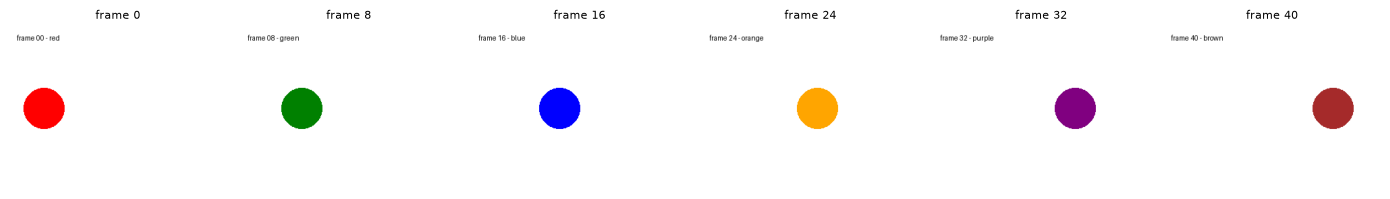

In [7]:
COLOURS = ["red", "green", "blue", "orange", "purple", "brown"]

def make_clip(n_frames=48, w=320, h=240):
    frames = []
    for i in range(n_frames):
        im = Image.new("RGB", (w, h), "white")
        d = ImageDraw.Draw(im)
        colour = COLOURS[i // 8]
        x = 20 + i * 5
        d.ellipse([x, 90, x + 60, 150], fill=colour)
        d.text((10, 10), f"frame {i:02d} - {colour}", fill="black")
        frames.append(im)
    return frames

frames = make_clip()
print(f"{len(frames)} frames, colour changes every 8")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 6, figsize=(14, 2.4))
for ax, i in zip(axes, [0, 8, 16, 24, 32, 40]):
    ax.imshow(frames[i]); ax.axis("off"); ax.set_title(f"frame {i}", fontsize=8)
plt.tight_layout(); plt.show()

In [8]:
messages = [{"role": "user", "content": [
    {"type": "video"},
    {"type": "text", "text": "List the colours of the circle in the order they appear."},
]}]
rendered = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
batch = processor(text=[rendered], videos=[frames], return_tensors="pt")

for k, v in batch.items():
    if hasattr(v, "shape"):
        print(f"  {k:22s} {tuple(v.shape)}")

n_video = int((batch["input_ids"] == processor.video_token_id).sum())
vp = processor.video_processor
print(f"\nsampled {batch['pixel_values_videos'].shape[1]} frames "
      f"(num_frames={vp.num_frames}, do_sample_frames={vp.do_sample_frames})")
print(f"max_soft_tokens for video: {vp.max_soft_tokens}   (images use "
      f"{processor.image_processor.max_soft_tokens})")
print(f"video tokens: {n_video}")
print(f"total prompt: {batch['input_ids'].shape[-1]} tokens")
print(f"\nA video frame is worth about a quarter of a still image. That is the trade")
print(f"that makes video fit in a prompt at all — and it predicts what the model will")
print(f"be bad at: narrative yes, fine detail no.")

[transformers] Gemma4 requires frame timestamps to construct prompts, but the `fps` of the input video could not be inferred. Probably `video_metadata` was missing from inputs and you passed pre-sampled frames. Defaulting to `fps=24`. Please provide `video_metadata` for more accurate results.


  input_ids              (1, 2324)
  attention_mask         (1, 2324)
  mm_token_type_ids      (1, 2324)
  pixel_values_videos    (1, 32, 630, 768)
  video_position_ids     (1, 32, 630, 2)

sampled 32 frames (num_frames=32, do_sample_frames=True)
max_soft_tokens for video: 70   (images use 280)
video tokens: 2016
total prompt: 2324 tokens

A video frame is worth about a quarter of a still image. That is the trade
that makes video fit in a prompt at all — and it predicts what the model will
be bad at: narrative yes, fine detail no.


In [9]:
inputs = batch.to(model.device, dtype=model.dtype)
input_len = inputs["input_ids"].shape[-1]
with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=200, do_sample=False)
print(processor.decode(out[0][input_len:], skip_special_tokens=True))
print("\nground truth:", COLOURS)

Here are the colors of the circles in the order they appear based on the provided images:

1. **Red** (frame 00)
2. **Red** (frame 01)
3. **Red** (frame 03)
4. **Red** (frame 04)
5. **Red** (frame 06)
6. **Red** (frame 07)
7. **Green** (frame 09)
8. **Green** (frame 10)
9. **Green** (frame 12)
10. **Green** (frame 13)
11. **Green** (frame 15)
12. **Blue** (frame 16)
13. **Blue** (frame 18)
14. **Blue** (frame 19)
15. **Blue** (frame

ground truth: ['red', 'green', 'blue', 'orange', 'purple', 'brown']


## 4. The `fps` trap

Time is carried in the prompt as literal `MM:SS` text ([chapter 02](../../02-text-io/index.md) §2) — not as a position encoding. If `fps` cannot be inferred, the processor warns and **assumes 24**.

In [10]:
import re
decoded = processor.tokenizer.decode(batch["input_ids"][0][:400], skip_special_tokens=False)
stamps = re.findall(r"\d{2}:\d{2}", decoded)
print("timestamps found in the prompt:", stamps[:10])
print()
print("Every one is 00:00 — and that is the trap, twice over.")
print()
print("1. We passed pre-sampled frames with no video_metadata, so fps defaulted to 24.")
print(f"   {len(frames)} frames at 24fps = {len(frames)/24:.1f}s of assumed duration.")
print("2. The format is MM:SS, so it has one-second granularity. A 2-second clip")
print("   sampled at 32 points collapses every stamp to 00:00.")
print()
print("The model therefore has NO temporal information about this clip beyond the")
print("frame order. If your source is 30fps, or your clip is minutes long, pass real")
print("video_metadata — otherwise the timestamps are either wrong or useless.")

timestamps found in the prompt: ['00:00', '00:00', '00:00', '00:00', '00:00', '00:00']

Every one is 00:00 — and that is the trap, twice over.

1. We passed pre-sampled frames with no video_metadata, so fps defaulted to 24.
   48 frames at 24fps = 2.0s of assumed duration.
2. The format is MM:SS, so it has one-second granularity. A 2-second clip
   sampled at 32 points collapses every stamp to 00:00.

The model therefore has NO temporal information about this clip beyond the
frame order. If your source is 30fps, or your clip is minutes long, pass real
video_metadata — otherwise the timestamps are either wrong or useless.


In [11]:
# frame count below num_frames is a hard error, not a silent pad
try:
    processor(text=[rendered], videos=[make_clip(n_frames=24)], return_tensors="pt")
except ValueError as e:
    print("ValueError:", e)

ValueError: Video can't be sampled. The `num_frames=32` exceeds `total_num_frames=24`. 


## Exercises

1. Chunk a 60-second clip into two 30-second halves, transcribe each, and stitch. What breaks at the boundary?
2. Ask a question whose answer is in the last 5 seconds of a 45-second clip passed whole. Does the model know it was truncated?
3. Raise the video processor's `max_soft_tokens` to 140 and re-ask the colour question. What does doubling the per-frame budget buy?
4. Set `num_frames=8`. Does the model still get the colour sequence right? Where is the floor?
5. Pass real `video_metadata` with the correct `fps` and diff the rendered timestamps against the default-24 version.
6. Compare the audio tower's parameter count with the vision tower's. Which modality did Gemma 4 spend more on, and does that match your intuition?

## Where next

[Chapter 06](../../06-text-decoder/index.md) — the decoder that all four modalities now feed.